In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
train_path = "/content/drive/MyDrive/dataset/train"
test_path = "/content/drive/MyDrive/dataset/test"

In [3]:
!ls /content/drive/MyDrive/

'Assignment speaking .gdoc'
'Colab Notebooks'
 Currículum.gdoc
 dataset
 gan_vs_wgan.ipynb
'Linear Regression OLS.ipynb'
'Programación Lineal.ipynb'
'Proyecto Base de datos.gdoc'
'Reporte de Proyecto.gdoc'
'Speaking Assignment - Level 4.gdoc'
'TAREA # 14. Análisis combinatorio y Variable'$'\n\n\n''Al....gsheet'


In [4]:
import os

print(os.path.exists(train_path))
print(os.path.exists(test_path))

True
True


## Conteo de imagenes

In [5]:
import os

train_files = os.listdir(train_path)
test_files = os.listdir(test_path)

print("Número de imágenes TRAIN:", len(train_files))
print("Número de imágenes TEST:", len(test_files))

Número de imágenes TRAIN: 500
Número de imágenes TEST: 100


## Visualizacion de Muestras

TRAIN:


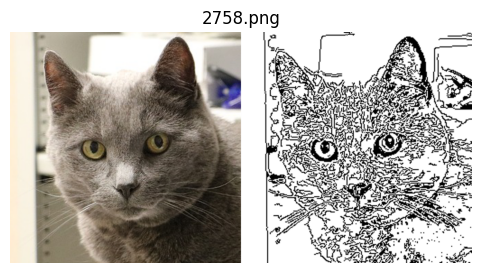

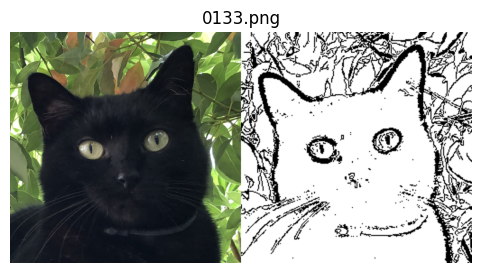

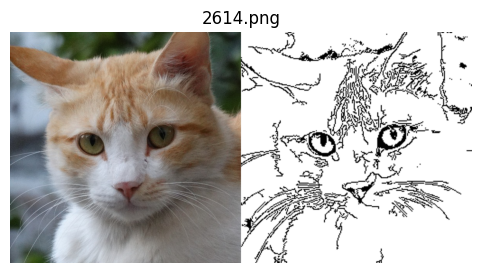

TEST:


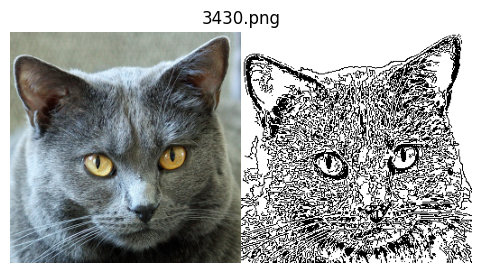

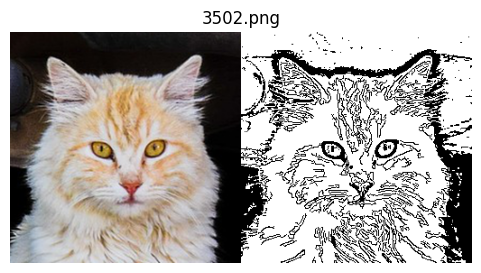

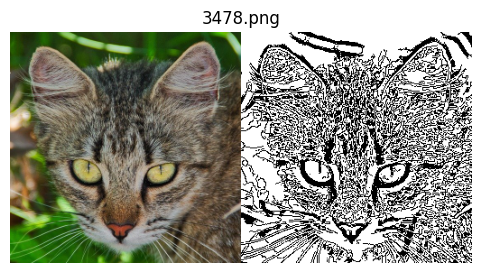

In [6]:
import cv2
import matplotlib.pyplot as plt
import random

def show_samples(path, n=3):
    files = os.listdir(path)
    samples = random.sample(files, n)

    for file in samples:
        img = cv2.imread(os.path.join(path, file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(6,3))
        plt.imshow(img)
        plt.title(file)
        plt.axis("off")
        plt.show()

print("TRAIN:")
show_samples(train_path)

print("TEST:")
show_samples(test_path)

## Separacion de Real contra Sketch

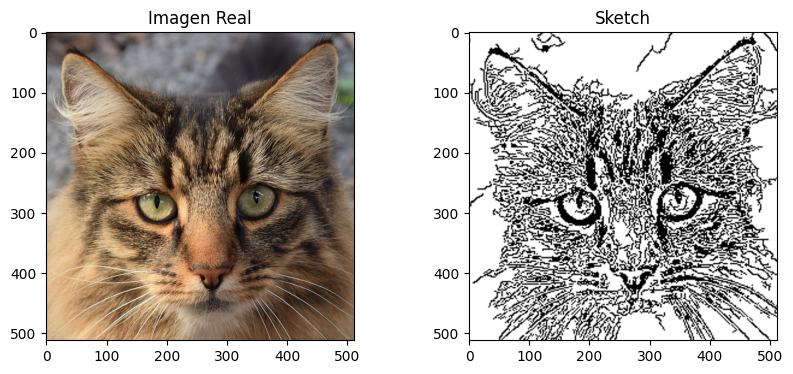

In [7]:
def split_image(img):
    h, w, _ = img.shape
    mid = w // 2
    A = img[:, :mid]
    B = img[:, mid:]
    return A, B

file = train_files[0]
img = cv2.imread(os.path.join(train_path, file))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

A, B = split_image(img)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(A)
plt.title("Imagen Real")

plt.subplot(1,2,2)
plt.imshow(B)
plt.title("Sketch")

plt.show()

## Tamaños de imagen

In [8]:
sizes = []

for file in train_files[:50]:
    img = cv2.imread(os.path.join(train_path, file))
    sizes.append(img.shape)

print("Ejemplos de tamaños:", sizes[:5])

Ejemplos de tamaños: [(512, 1024, 3), (512, 1024, 3), (512, 1024, 3), (512, 1024, 3), (512, 1024, 3)]


## Estadistics Basicas

In [9]:
import numpy as np

means = []
stds = []

for file in train_files[:50]:
    img = cv2.imread(os.path.join(train_path, file))
    img = img / 255.0
    means.append(np.mean(img))
    stds.append(np.std(img))

print("Media promedio:", np.mean(means))
print("Std promedio:", np.mean(stds))

Media promedio: 0.6047864458670024
Std promedio: 0.33984595638778686


## Comparar real vs sketch

In [10]:
real_means = []
sketch_means = []

for file in train_files[:50]:
    img = cv2.imread(os.path.join(train_path, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    A, B = split_image(img)

    real_means.append(np.mean(A))
    sketch_means.append(np.mean(B))

print("Media REAL:", np.mean(real_means))
print("Media SKETCH:", np.mean(sketch_means))

Media REAL: 113.28945737202963
Media SKETCH: 195.1516300201416


## Promedio de imagen

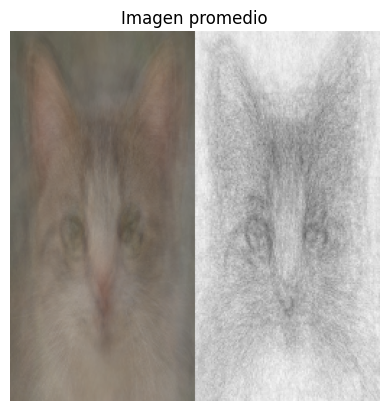

In [12]:
avg_img = None

for file in train_files[:50]:
    img = cv2.imread(os.path.join(train_path, file))
    img = cv2.resize(img, (256,256))

    if avg_img is None:
        avg_img = img.astype(float)
    else:
        avg_img += img

avg_img /= 50
avg_img = avg_img.astype("uint8")

plt.imshow(cv2.cvtColor(avg_img, cv2.COLOR_BGR2RGB))
plt.title("Imagen promedio")
plt.axis("off")
plt.show()

## Comparacion Estructural

In [13]:
edges_strength = []

for file in train_files[:50]:
    img = cv2.imread(os.path.join(train_path, file))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 50, 150)
    edges_strength.append(np.mean(edges))

print("Promedio de bordes:", np.mean(edges_strength))

Promedio de bordes: 37.30307865142822


In [14]:
total = len(train_files) + len(test_files)

print("Train %:", len(train_files)/total)
print("Test %:", len(test_files)/total)

Train %: 0.8333333333333334
Test %: 0.16666666666666666
